# Class 4 - Feature Selection

Yelp Restaurants Module 3 lab notebook. This notebook is organized for GitHub review and uses the final clean dataset produced by `scripts/run_pipeline.py`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from yelp_lab.config import FINAL_SCHEMA

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "yelp_restaurants_clean.parquet"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "classes"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DISPLAY_DIR = PROJECT_ROOT / ".cache" / "notebook_figures"
NOTEBOOK_DISPLAY_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
_display_counter = 0

def show_and_close():
    global _display_counter
    for number in plt.get_fignums():
        _display_counter += 1
        fig = plt.figure(number)
        display_path = NOTEBOOK_DISPLAY_DIR / f"figure_{_display_counter:03d}.png"
        fig.savefig(display_path, dpi=160, bbox_inches="tight")
        display(Image(filename=str(display_path)))
    plt.close("all")

plt.show = show_and_close

print(df.shape)
df.head()

(5852, 22)


,business_id,state,city,latitude,longitude,dist_from_center,n_categories,price_range_num,has_wifi,has_parking,...,alcohol_num,noise_level_num,hours_open_per_week,n_days_open,review_count,log_review_count,review_velocity,mean_review_length,mean_review_sentiment_score,stars
0,MTSW4McQd7CbVtyjqoe9mw,PA,Philadelphia,39.955505,-75.155564,0.882586,5,1,1,1,...,0,0,94.0,7,80,4.394449,6.374473,558.919540,2.160920,4.0
1,MUTTqe8uqyMdBl186RmNeA,PA,Philadelphia,39.953949,-75.143226,1.879011,3,2,1,1,...,2,2,53.0,6,245,5.505332,60.471854,647.640000,3.772000,4.0
2,ROeacJQwBeh05Rqg7F6TCg,PA,Philadelphia,39.943223,-75.162568,1.066541,2,1,0,1,...,0,1,54.0,6,205,5.327876,25.700947,432.432692,2.533654,4.5
3,QdN72BWoyFypdGJhhI5r7g,PA,Philadelphia,39.939825,-75.157447,1.566801,5,2,1,1,...,2,2,78.0,7,65,4.189655,20.932101,514.275362,2.826087,4.0
4,Mjboz24M9NlBeiOJKLEd_Q,PA,Philadelphia,40.022466,-75.218314,8.990560,4,1,0,0,...,0,2,41.0,6,41,3.737670,7.779351,470.146341,1.000000,3.0


## Goal

Reduce the engineered dataset to a useful set of predictive columns and explain which features matter most.

Original PDF tasks:
- Split train/test before scoring features.
- Inspect correlations.
- Compute mutual information.
- Train Random Forest feature importance as a second opinion.
- Mark AT-LAUNCH vs AFTER-REVIEWS features.
- Make 3+ exploratory charts and 1 explanatory chart.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split

feature_df = df.drop(columns=["business_id", "stars"])
feature_df = pd.get_dummies(feature_df, columns=["state", "city"], drop_first=False)
X = feature_df
y = df["stars"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(4681, 20) (1171, 20)


## Exploratory Chart 1 - Correlation Heatmap

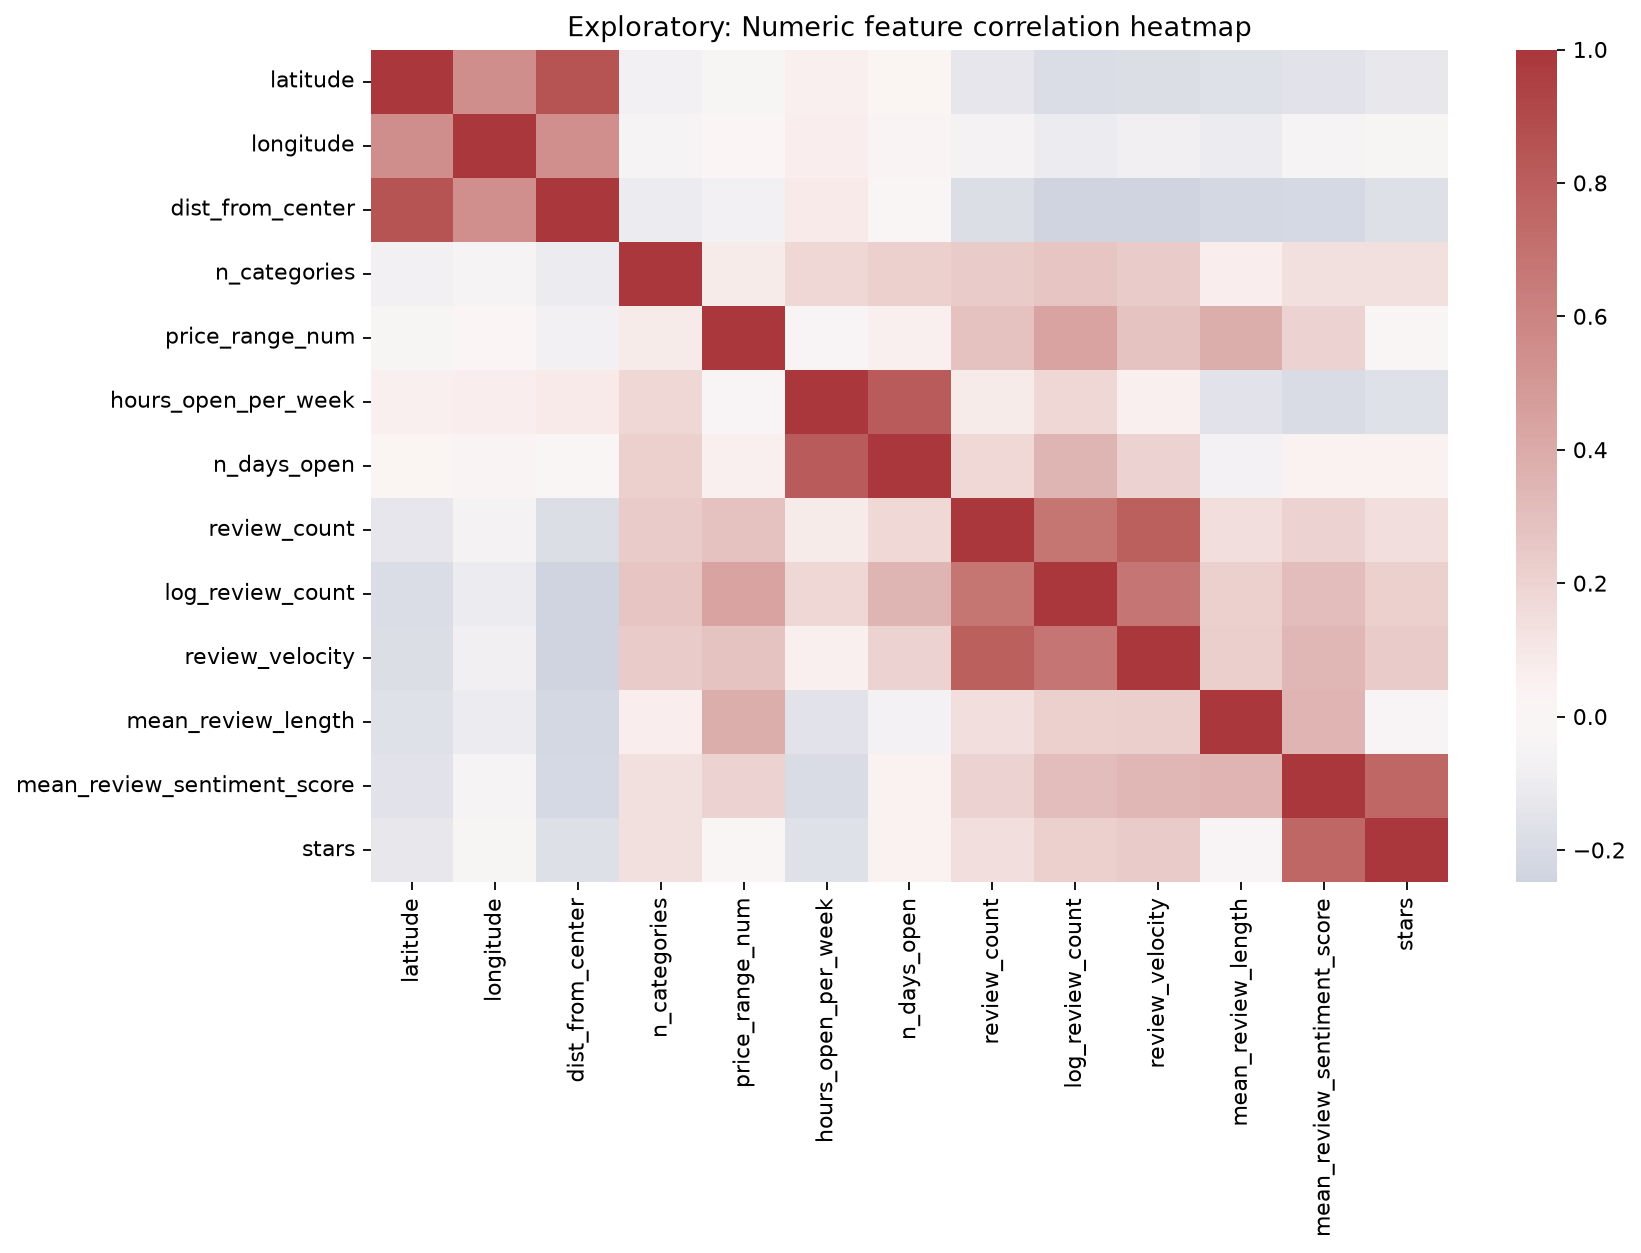

In [3]:
corr_cols = [
    "latitude", "longitude", "dist_from_center", "n_categories", "price_range_num",
    "hours_open_per_week", "n_days_open", "review_count", "log_review_count",
    "review_velocity", "mean_review_length", "mean_review_sentiment_score", "stars"
]
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df[corr_cols].corr(), cmap="vlag", center=0, ax=ax)
ax.set_title("Exploratory: Numeric feature correlation heatmap")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class4_exploratory_correlation_heatmap.png", dpi=160)
plt.show()

## Exploratory Chart 2 - Mutual Information Scores

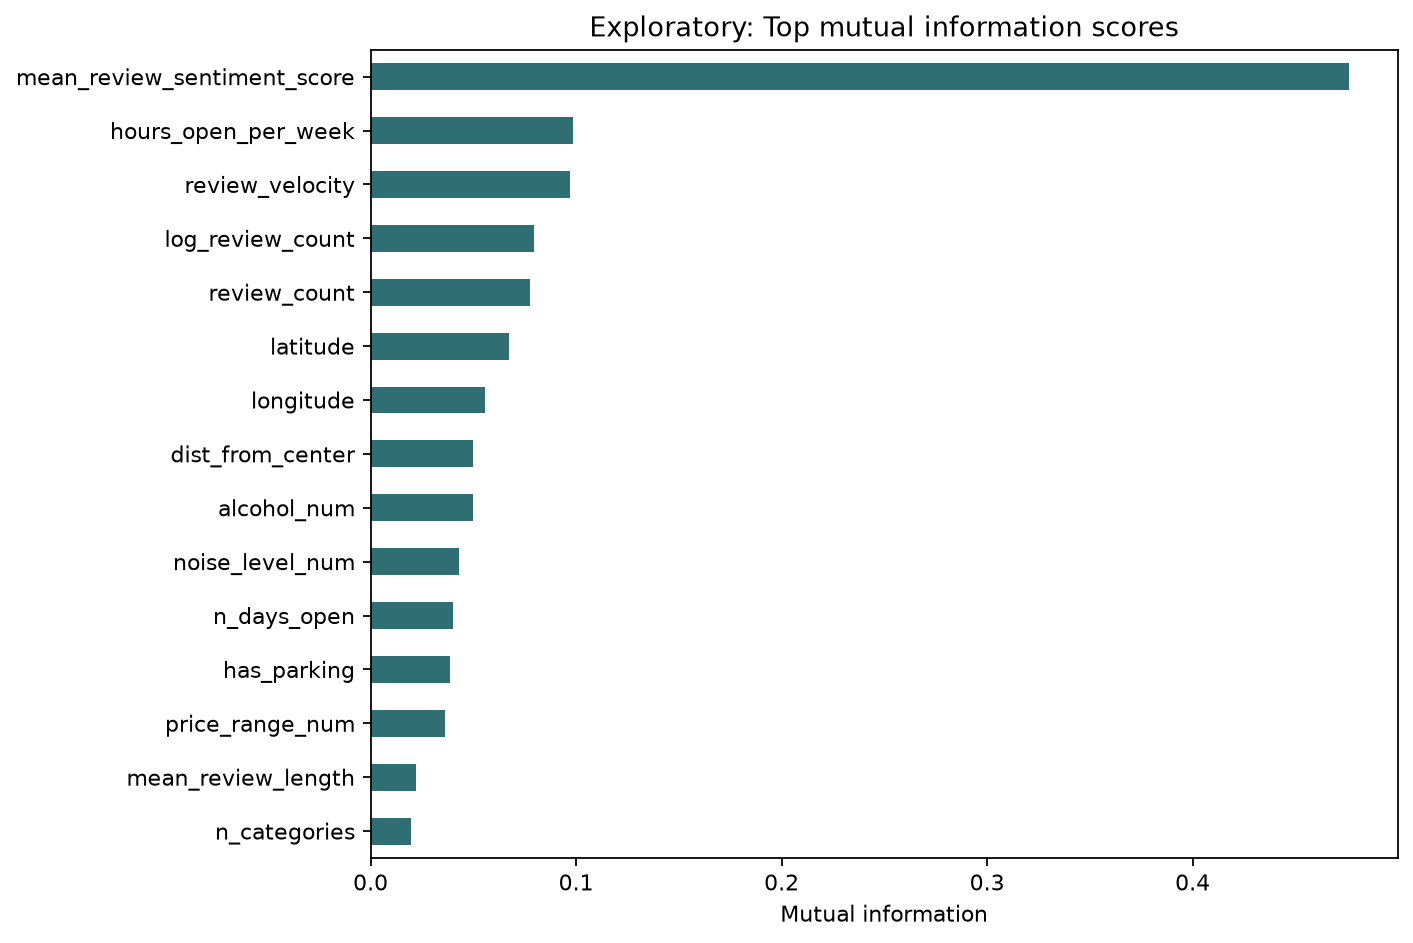

In [4]:
mi = pd.Series(mutual_info_regression(X_train, y_train, random_state=42), index=X_train.columns)
mi_top = mi.sort_values().tail(15)
fig, ax = plt.subplots(figsize=(9, 6))
mi_top.plot(kind="barh", ax=ax, color="#2f6f73")
ax.set_title("Exploratory: Top mutual information scores")
ax.set_xlabel("Mutual information")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class4_exploratory_mutual_info.png", dpi=160)
plt.show()

## Exploratory Chart 3 - Random Forest Importances

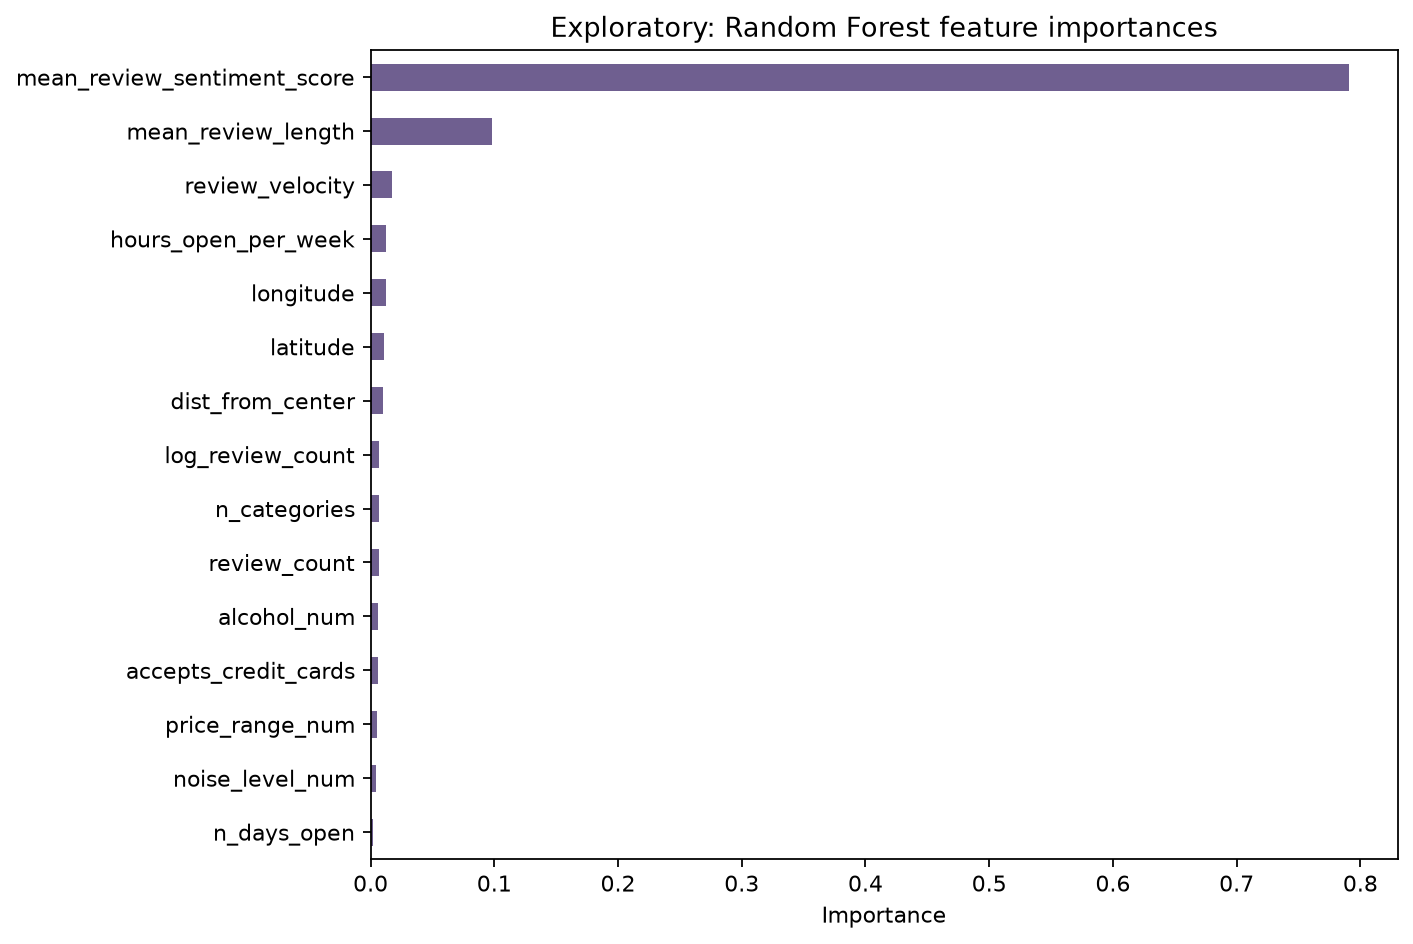

In [5]:
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
rf_importance.tail(15).plot(kind="barh", ax=ax, color="#6f5f90")
ax.set_title("Exploratory: Random Forest feature importances")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class4_exploratory_rf_importance.png", dpi=160)
plt.show()

## Explanatory Chart for Priya - Top 15 Predictors

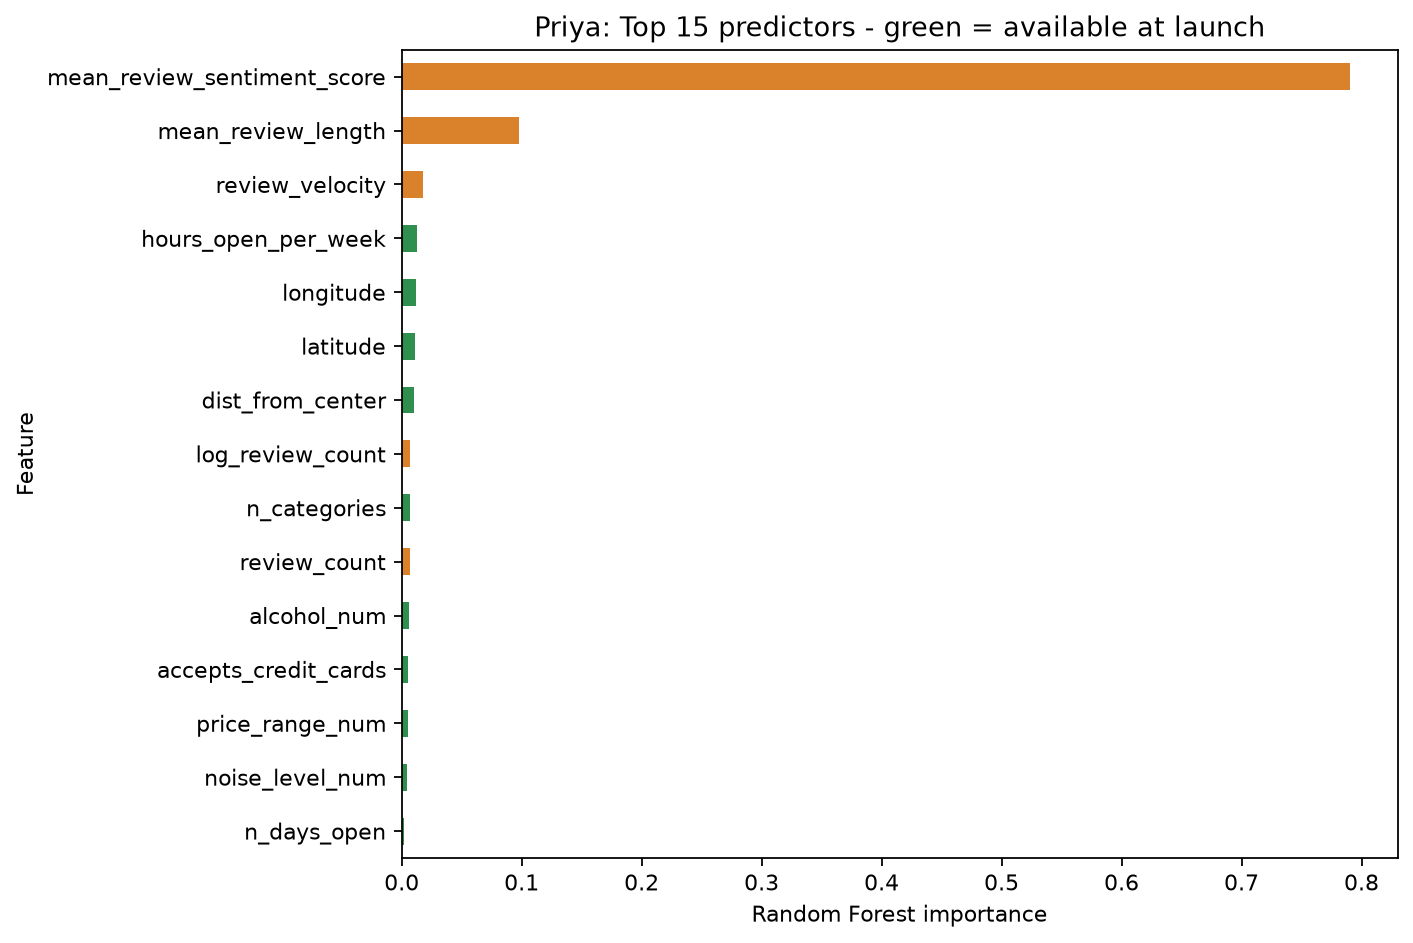

Takeaway: Review-based features are strongest, but launch-time metadata still provides usable cold-start signals.


In [6]:
at_launch = {
    "state_PA", "city_Philadelphia", "latitude", "longitude", "dist_from_center",
    "n_categories", "price_range_num", "has_wifi", "has_parking",
    "accepts_credit_cards", "outdoor_seating", "alcohol_num",
    "noise_level_num", "hours_open_per_week", "n_days_open"
}
top = rf_importance.tail(15)
colors = ["#2f8f4e" if name in at_launch else "#d9822b" for name in top.index]
fig, ax = plt.subplots(figsize=(9, 6))
top.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Priya: Top 15 predictors - green = available at launch")
ax.set_xlabel("Random Forest importance")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "class4_explanatory_top_predictors.png", dpi=160)
plt.show()
print("Takeaway: Review-based features are strongest, but launch-time metadata still provides usable cold-start signals.")

## Selected Feature Notes

Kept features are the 22 final-schema columns. Features based on reviews are marked AFTER-REVIEWS because they are not available for a brand-new restaurant. Location, hours, price, and attributes are AT-LAUNCH features.